# 1. Подготовка

Импортируем библиотеки, необходимые для выполнения задания

In [7]:
import numpy as np
import pandas as pd
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.model_selection import train_test_split, KFold
from sklearn.datasets import make_classification
from sklearn.preprocessing import StandardScaler, LabelEncoder
from keras.models import Sequential
from keras.layers import Dense, Dropout, LeakyReLU, BatchNormalization
from keras.callbacks import EarlyStopping, LearningRateScheduler
from keras.optimizers import Adam
from keras.regularizers import l2

## Прочитаем файл

In [8]:
df = pd.read_csv('Titanic.csv').drop('PassengerId', axis=1)#сразу убираем столбик с ID, так как он не поможет в решении задачи (не несет полезной метрики)
df

,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S
...,...,...,...,...,...,...,...,...,...,...,...
886,0,2,"Montvila, Rev. Juozas",male,27.0,0,0,211536,13.0000,NaN,S
887,1,1,"Graham, Miss. Margaret Edith",female,19.0,0,0,112053,30.0000,B42,S
888,0,3,"Johnston, Miss. Catherine Helen ""Carrie""",female,NaN,1,2,W./C. 6607,23.4500,NaN,S
889,1,1,"Behr, Mr. Karl Howell",male,26.0,0,0,111369,30.0000,C148,C


In [9]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 11 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   Survived  891 non-null    int64  
 1   Pclass    891 non-null    int64  
 2   Name      891 non-null    object 
 3   Sex       891 non-null    object 
 4   Age       714 non-null    float64
 5   SibSp     891 non-null    int64  
 6   Parch     891 non-null    int64  
 7   Ticket    891 non-null    object 
 8   Fare      891 non-null    float64
 9   Cabin     204 non-null    object 
 10  Embarked  889 non-null    object 
dtypes: float64(2), int64(4), object(5)
memory usage: 76.7+ KB



PassengerId: Уникальный идентификатор для каждого пассажира.

Survived: выжил или нет

Pclass: Класс каюты, в котором находился пассажир.

Name: Имя пассажира.

Sex: Пол пассажира.

Age: Возраст пассажира.

SibSp: Кол-во родственников

Parch: Количество людей, сопровождающих пассажира.

Ticket: Номер билета пассажира.

Fare: Стоимость билета

Cabin: Номер каюты

Embarked: Порт посадки пассажира.

# 2.Составим гипотезы #TODO Полина

##Гипотеза о поле: H1 - Женщины имеют больший шансы выживания, чем мужчины

Проверим это:

Среди мужчины выжило: 74.2%
Среди женщины выжило: 18.9%


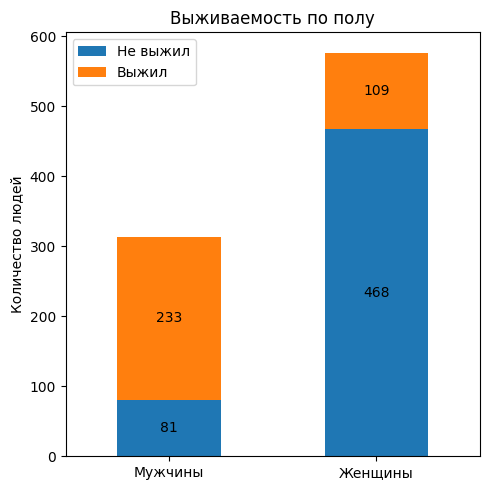

In [10]:
# 1. Подготовка данных с русскими названиями
stats = df.groupby('Sex')['Survived'].value_counts().unstack()
stats.columns = ['Не выжил', 'Выжил']
stats.index = ['Мужчины', 'Женщины']

# 2. Вывод статистики
for sex in stats.index:
    total = stats.loc[sex].sum()
    survived = stats.loc[sex, 'Выжил']
    print(f'Среди {sex.lower()} выжило: {round(survived/total*100, 1)}%')

# 3. Построение графика
ax = stats.plot(kind='bar', stacked=True, figsize=(5, 5))
plt.title('Выживаемость по полу')
plt.ylabel('Количество людей')


# Добавляем подписи значений
for container in ax.containers:
    ax.bar_label(container, label_type='center')

# Улучшаем читаемость
plt.xticks(rotation=0)  # Горизонтальные подписи категорий
plt.tight_layout()  # Автоматическая подгонка отступов

plt.show()

Наша гипотеза подтверждена - женщины выживали чаще, о чем свидетельствуют процентное соотношение (74.2% vs 18.9%) и наглядная диаграмма

##Гипотеза о возрасте: как мы знаем, детям также давали спасательные лодки в первую очередь, следовательно: Н2 - дети (18< лет) выживали чаще

Среди дети выжило: 54.0%
Среди все пассажиры выжило: 38.4%


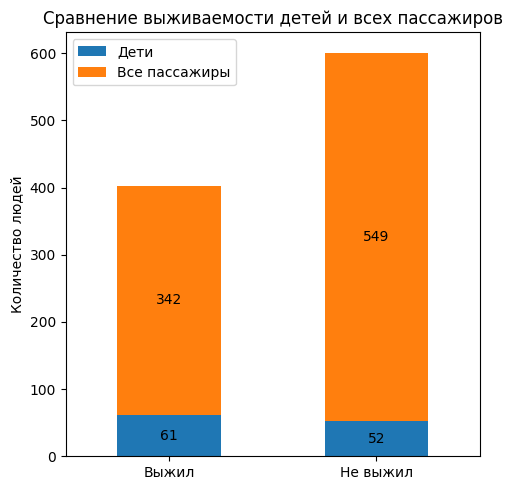

In [11]:
# 1. Подготовка данных с русскими названиями
# Фильтруем детей (возраст < 18 и не пустой)
children_df = df[(df['Age'] < 18) & (df['Age'].notna())]
stats = pd.DataFrame({
    'Дети': [
        len(children_df[children_df['Survived'] == 1]),  # Выжил
        len(children_df[children_df['Survived'] == 0])   # Не выжил
    ],
    'Все пассажиры': [
        len(df[df['Survived'] == 1]),  # Выжил
        len(df[df['Survived'] == 0])   # Не выжил
    ]
}, index=['Выжил', 'Не выжил'])  # Это теперь строки (индекс)

# 2. Вывод статистики
for group in stats.columns:  # Итерируем по столбцам (группам)
    total = stats[group].sum()
    survived = stats.loc['Выжил', group]
    print(f'Среди {group.lower()} выжило: {round(survived/total*100, 1)}%')

# 3. Построение графика
ax = stats.plot(kind='bar', stacked=True, figsize=(5, 5))
plt.title('Сравнение выживаемости детей и всех пассажиров')
plt.ylabel('Количество людей')
plt.xlabel('')

# 4. Добавление подписей значений
for container in ax.containers:
    ax.bar_label(container, label_type='center')

# 5. Настройка отображения
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

Гипотеза подвердилась - и по графику, и через процентное соотношение видно, что дети выживали чаще

##Также чаще всего в первую очередь спасали пожилых людей: Н3 - пожилые люди спасались чаще (< 60 лет)


Процент выживших:
Пожилые (60+): 26.9% выживших
Все пассажиры: 38.4% выживших


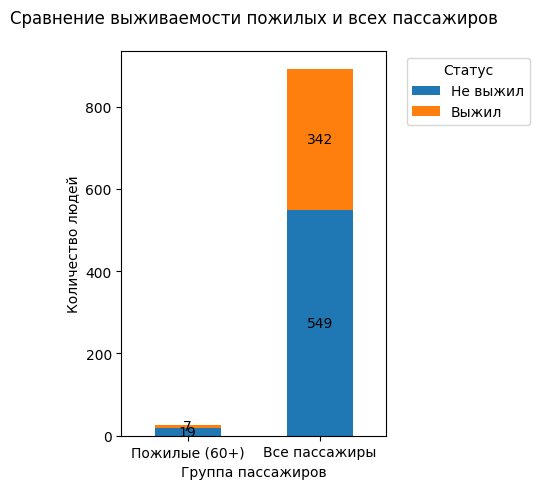

In [12]:
# 1. Подготовка данных
# Фильтруем пожилых пассажиров (возраст >= 60 и не пустой)
elderly_df = df[(df['Age'] >= 60) & (df['Age'].notna())]

# Создаем DataFrame с нужной структурой
stats = pd.DataFrame({
    'Пожилые (60+)': {
        'Не выжил': len(elderly_df[elderly_df['Survived'] == 0]),
        'Выжил': len(elderly_df[elderly_df['Survived'] == 1])
    },
    'Все пассажиры': {
        'Не выжил': len(df[df['Survived'] == 0]),
        'Выжил': len(df[df['Survived'] == 1])
    }
})

# 2. Вывод статистики
print("\nПроцент выживших:")
for group in stats.columns:
    total = stats[group].sum()
    survived = stats[group]['Выжил']
    print(f"{group}: {round(survived/total*100, 1)}% выживших")

# 3. Построение графика, вариант 1
ax = stats.T.plot(kind='bar', stacked=True, figsize=(5, 5))
plt.title('Сравнение выживаемости пожилых и всех пассажиров', pad=20)
plt.ylabel('Количество людей')
plt.xlabel('Группа пассажиров')

# 4. Добавление подписей значений
for container in ax.containers:
    ax.bar_label(container, label_type='center')

# 5. Настройка отображения
plt.xticks(rotation=0)
plt.legend(title='Статус', bbox_to_anchor=(1.05, 1))
plt.tight_layout()
plt.show()

Получился "плохой" график (для пожилых числа наехали друг на друга), реализуем функцию построения иначе

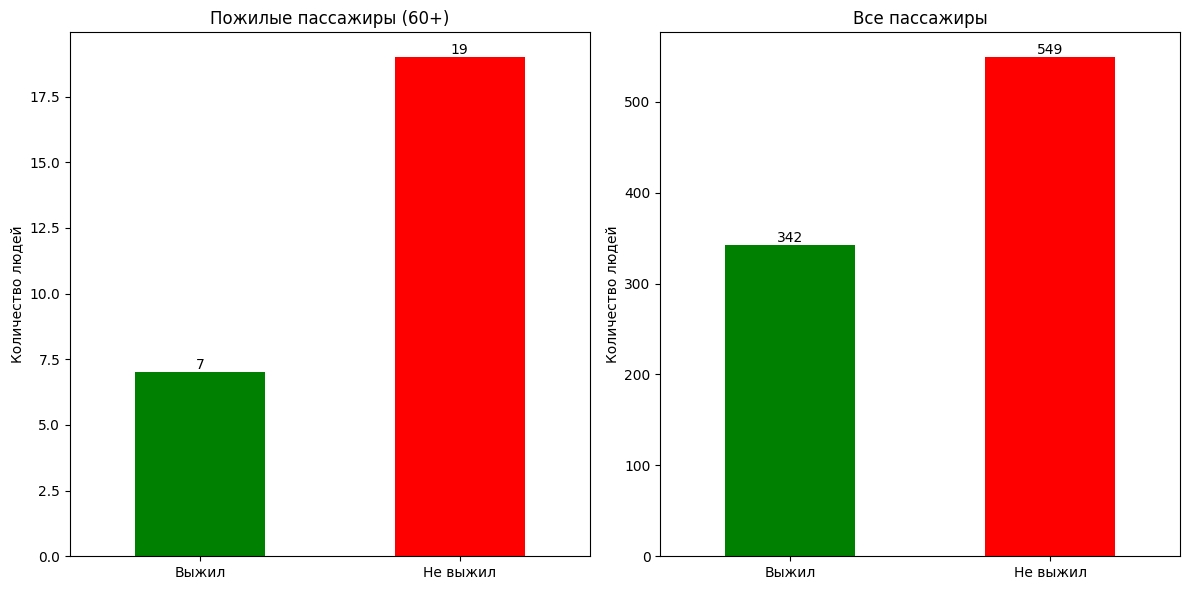

Среди Пожилые (60+): выжило 26.9% (7/26)
Среди Все пассажиры: выжило 38.4% (342/891)


In [13]:
# 1. Подготовка данных
elderly_df = df[(df['Age'] >= 60) & (df['Age'].notna())]
stats = pd.DataFrame({
    'Пожилые (60+)': [
        len(elderly_df[elderly_df['Survived'] == 1]),  # Выжил
        len(elderly_df[elderly_df['Survived'] == 0])   # Не выжил
    ],
    'Все пассажиры': [
        len(df[df['Survived'] == 1]),  # Выжил
        len(df[df['Survived'] == 0])   # Не выжил
    ]
}, index=['Выжил', 'Не выжил'])

# Вариант 2
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 6))
stats['Пожилые (60+)'].plot(kind='bar', ax=ax1, color=['green', 'red'])
stats['Все пассажиры'].plot(kind='bar', ax=ax2, color=['green', 'red'])

ax1.set_title('Пожилые пассажиры (60+)')
ax2.set_title('Все пассажиры')
for ax in [ax1, ax2]:
    ax.set_ylabel('Количество людей')
    ax.set_xticklabels(['Выжил', 'Не выжил'], rotation=0)
    for p in ax.patches:
        ax.annotate(str(p.get_height()), (p.get_x() + p.get_width()/2., p.get_height()),
                    ha='center', va='center', xytext=(0, 5), textcoords='offset points')

plt.tight_layout()
plt.show()

# 3. Вывод процентных соотношений
for group in stats.columns:
    total = stats[group].sum()
    survived_pct = stats.loc['Выжил', group]/total*100
    print(f'Среди {group}: выжило {round(survived_pct, 1)}% ({stats.loc["Выжил", group]}/{total})')

Гипотеза не подтвердилась -
что по графикам, что через процентное соотношение явно видно, что пожилые люди имели меньший шанс на выживание

## Проверим еще одну гипотезу: Н4 - чем выше класс (у любой категории пассажиров (любой пол, возраст)), тем выше шанс выжить


Процент выживших по классам:
1 класс: 63.0% выживших
2 класс: 47.3% выживших
3 класс: 24.2% выживших


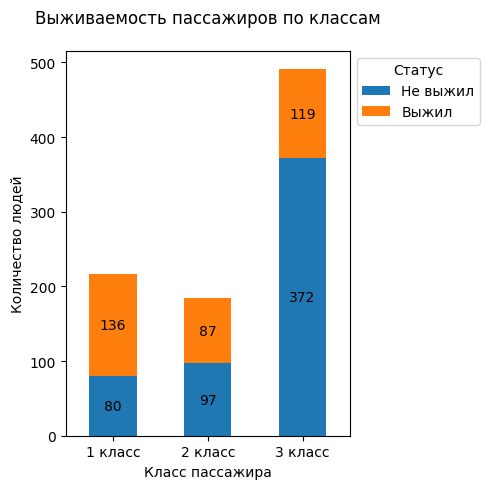

In [14]:
# 1. Подготовка данных
# Группируем по классу и выжившим/невыжившим
survival_stats = df.groupby(['Pclass', 'Survived']).size().unstack()

# Создаем DataFrame с нужной структурой
stats = pd.DataFrame({
    '1 класс': {
        'Не выжил': survival_stats.loc[1, 0],
        'Выжил': survival_stats.loc[1, 1]
    },
    '2 класс': {
        'Не выжил': survival_stats.loc[2, 0],
        'Выжил': survival_stats.loc[2, 1]
    },
    '3 класс': {
        'Не выжил': survival_stats.loc[3, 0],
        'Выжил': survival_stats.loc[3, 1]
    }
})

# 2. Вывод статистики
print("\nПроцент выживших по классам:")
for group in stats.columns:
    total = stats[group].sum()
    survived = stats[group]['Выжил']
    print(f"{group}: {round(survived/total*100, 1)}% выживших")

# 3. Построение графика
ax = stats.T.plot(kind='bar', stacked=True, figsize=(5, 5))
plt.title('Выживаемость пассажиров по классам', pad=20)
plt.ylabel('Количество людей')
plt.xlabel('Класс пассажира')

# 4. Добавление подписей значений
for container in ax.containers:
    ax.bar_label(container, label_type='center')

# 5. Настройка отображения
plt.xticks(rotation=0)
plt.legend(title='Статус', bbox_to_anchor=(1, 1))
plt.tight_layout()
plt.show()

Наша гипотеза подтвердилась: чем выше класс - тем бОльший шанс на выживание у пассажира

##Гипотеза о родственниках: Н5 - чаще выживали люди, если у них были родственники на борту


Процент выживших:
Пассажиры с родственниками: 46.64% выживших
Все пассажиры: 38.38% выживших


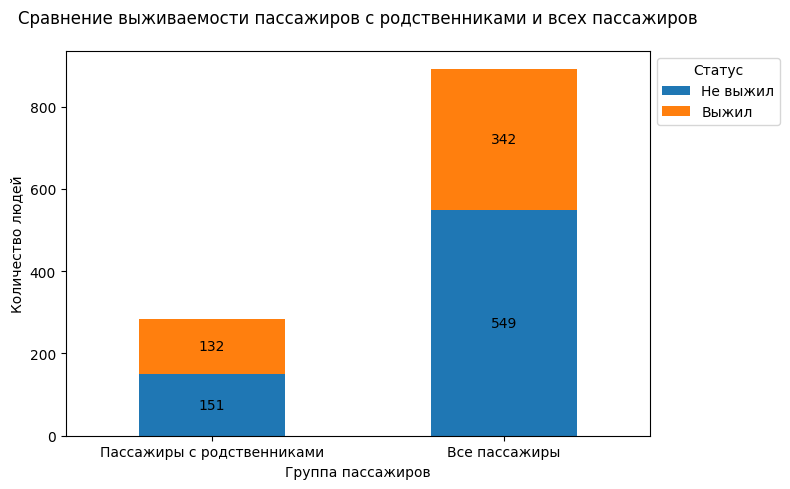

In [15]:
# Фильтруем пассажиров с родственниками
passengers_with_relatives = df[df['SibSp'] >= 1]

# Создаем DataFrame с нужной структурой
stats = pd.DataFrame({
    'Пассажиры с родственниками': {
        'Не выжил': len(passengers_with_relatives[passengers_with_relatives['Survived'] == 0]),
        'Выжил': len(passengers_with_relatives[passengers_with_relatives['Survived'] == 1])
    },
    'Все пассажиры': {
        'Не выжил': len(df[df['Survived'] == 0]),
        'Выжил': len(df[df['Survived'] == 1])
    }
})

# 2. Вывод статистики
print("\nПроцент выживших:")
for group in stats.columns:
    total = stats[group].sum()
    survived = stats[group]['Выжил']
    print(f"{group}: {round(survived/total*100, 2)}% выживших")

# 3. Построение графика
ax = stats.T.plot(kind='bar', stacked=True, figsize=(8, 5))
plt.title('Сравнение выживаемости пассажиров с родственниками и всех пассажиров', pad=20)
plt.ylabel('Количество людей')
plt.xlabel('Группа пассажиров')

# 4. Добавление подписей значений
for container in ax.containers:
    ax.bar_label(container, label_type='center')

# 5. Настройка отображения
plt.xticks(rotation=0)
plt.legend(title='Статус', bbox_to_anchor=(1, 1))
plt.tight_layout()
plt.show()

Гипотеза подтвердилась - наличие родственников на борту повышало шансы на выживание

Если смотреть на датасет, то, пожалуй, что еще можно проверить - порт отправления

*Также можно посмотреть на стоимость билета, но она скорее всего будет линельно (с погрешностями) от класса

На всякий случай проверим зависимость класса от стоимости билета


Статистика стоимости билетов по классам:
                  mean  median    std  min     max
Pclass_category                                   
1 класс          84.15   60.29  78.38  0.0  512.33
2 класс          20.66   14.25  13.42  0.0   73.50
3 класс          13.68    8.05  11.78  0.0   69.55


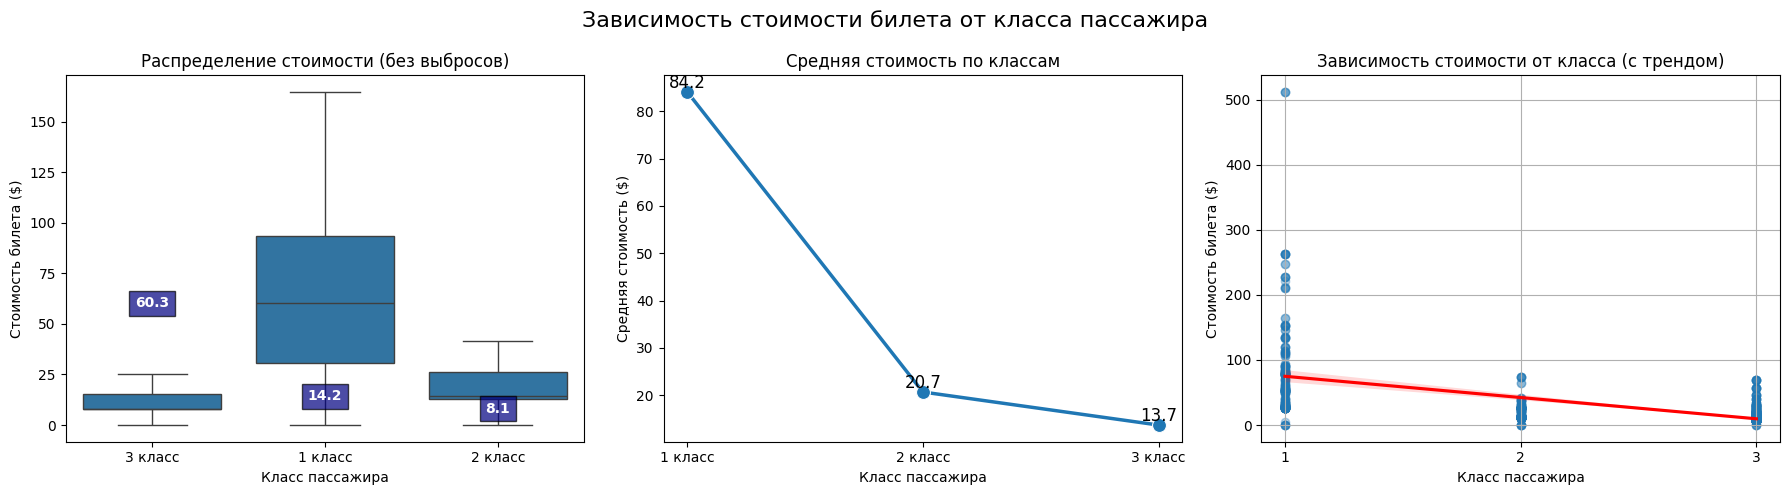

In [16]:
# Создаем категории классов для лучшей визуализации
df['Pclass_category'] = df['Pclass'].map({1: '1 класс', 2: '2 класс', 3: '3 класс'})

# 2. Вывод статистики
print("\nСтатистика стоимости билетов по классам:")
stats = df.groupby('Pclass_category')['Fare'].agg(['mean', 'median', 'std', 'min', 'max'])
print(stats.round(2))

# 3. Настройка стиля графиков
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle('Зависимость стоимости билета от класса пассажира', fontsize=16)

# График 1: Boxplot распределения стоимости по классам
sns.boxplot(x='Pclass_category', y='Fare', data=df, ax=axes[0], showfliers=False)
axes[0].set_title('Распределение стоимости (без выбросов)')
axes[0].set_xlabel('Класс пассажира')
axes[0].set_ylabel('Стоимость билета ($)')

# Добавляем аннотации с медианой
for i, pclass in enumerate(['1 класс', '2 класс', '3 класс']):
    median_val = df[df['Pclass_category'] == pclass]['Fare'].median()
    axes[0].text(i, median_val, f'{median_val:.1f}',
                ha='center', va='center', fontweight='bold', color='white',
                bbox=dict(facecolor='navy', alpha=0.7))

# График 2: Линейная зависимость средних значений
mean_fares = df.groupby('Pclass_category')['Fare'].mean().reset_index()
sns.lineplot(x='Pclass_category', y='Fare', data=mean_fares,
             marker='o', markersize=10, ax=axes[1], linewidth=2.5)
axes[1].set_title('Средняя стоимость по классам')
axes[1].set_xlabel('Класс пассажира')
axes[1].set_ylabel('Средняя стоимость ($)')

# Добавляем значения точек
for i, row in mean_fares.iterrows():
    axes[1].text(row['Pclass_category'], row['Fare'], f'{row["Fare"]:.1f}',
                ha='center', va='bottom', fontsize=12)

# График 3: Scatter plot с трендом
sns.regplot(x='Pclass', y='Fare', data=df, ax=axes[2],
            scatter_kws={'alpha':0.3}, line_kws={'color':'red'})
axes[2].set_title('Зависимость стоимости от класса (с трендом)')
axes[2].set_xlabel('Класс пассажира')
axes[2].set_ylabel('Стоимость билета ($)')
axes[2].set_xticks([1, 2, 3])
axes[2].grid(True)

# 4. Общие настройки
plt.tight_layout()
plt.subplots_adjust(top=0.85)  # Добавляем место для общего заголовка
plt.show()

Как видим - класс сопоставляется со стоимостью билета, что в целом было очевидно

Поэтому не будем проверять зависимость шанса выжить от стоимости


# Гипотеза о портах: H6 - а что если порт влиял на шанс выжить

Для лучшего понимания будем использовать круговую диаграмму

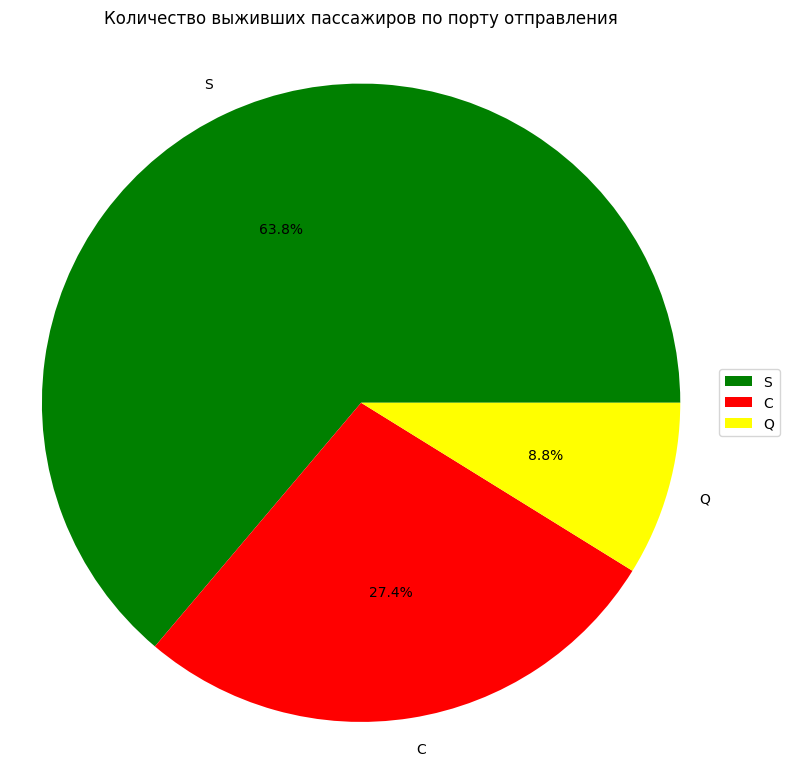

Вероятность выжить, если ты из порта S 63.45%
Вероятность выжить, если ты из порта Q 8.77%
Вероятность выжить, если ты из порта C 27.19%


In [17]:
survived = df[df['Survived'] == 1]

counts = survived['Embarked'].value_counts()

plt.figure(figsize=(8, 8))
wedges, texts, autotexts = plt.pie(counts.values, labels=counts.index, autopct='%1.1f%%',
                                   colors=['green', 'red', 'yellow'])

# Добавляем легенду
plt.legend(wedges, counts.index,
          loc="center left",
          bbox_to_anchor=(1, 0, 0.5, 1))

# Добавляем заголовок
plt.title('Количество выживших пассажиров по порту отправления')

# Отображаем график
plt.axis('equal')  # Чтобы круговая диаграмма была равнобедренной
plt.tight_layout()
plt.show()

#Для вывода процентов
survivors = len(df.loc[(df['Survived']==1)])
survived_S = len(df.loc[((df['Embarked'] == 'S') & (df['Survived'] == 1))])
print(f'Вероятность выжить, если ты из порта S {round(survived_S*100/survivors, 2)}%')
survived_Q = len(df.loc[((df['Embarked'] == 'Q') & (df['Survived'] == 1))])
print(f'Вероятность выжить, если ты из порта Q {round(survived_Q*100/survivors, 2)}%')
survived_C = len(df.loc[((df['Embarked'] == 'C') & (df['Survived'] == 1))])
print(f'Вероятность выжить, если ты из порта C {round(survived_C*100/survivors, 2)}%')

Из графика видим, что больше всего выживших больше всего из порта S

Но не будем обольщаться - вдруг из этого порта в целом больше всего пассажиров

Следовательно проверим кол-во пассажиров, которые присоединились в том или ином порту

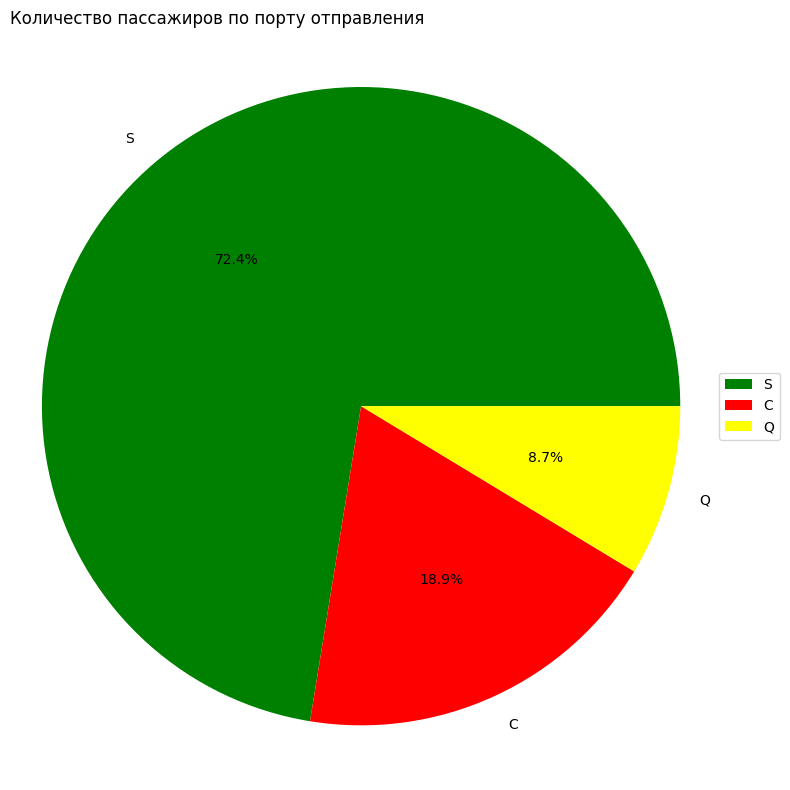

In [18]:
#Группируем
counts = df['Embarked'].value_counts()

#Реализуем графики
plt.figure(figsize=(8, 8))
wedges, texts, autotexts = plt.pie(counts.values, labels=counts.index, autopct='%1.1f%%',
                                   colors=['green', 'red', 'yellow'])

# Добавляем легенду
plt.legend(wedges, counts.index,
          loc="center left",
          bbox_to_anchor=(1, 0, 0.5, 1))

# Добавляем заголовок
plt.title('Количество пассажиров по порту отправления',
          loc="left")

# Отображаем график
plt.axis('equal')  # Чтобы круговая диаграмма была равнобедренной
plt.tight_layout()
plt.show()

Да, так и есть - большинство сели в порту S

Однако, это не отменяет того факта, что вероятность выживаниия выше, если пассажир из порта S

А что если влияла первая буква в номере кабины - ведь это прямое расположение кабины на Титанике

Большинство пассажиров могло находиться в каютах, в силу того, что крушение произошло под ночь



Процент выживших по первой букве каюты:
Unknown: 30.0% выживших
A: 46.7% выживших
B: 74.5% выживших
C: 59.3% выживших
D: 75.8% выживших
E: 75.0% выживших
F: 61.5% выживших
G: 50.0% выживших
T: 0.0% выживших


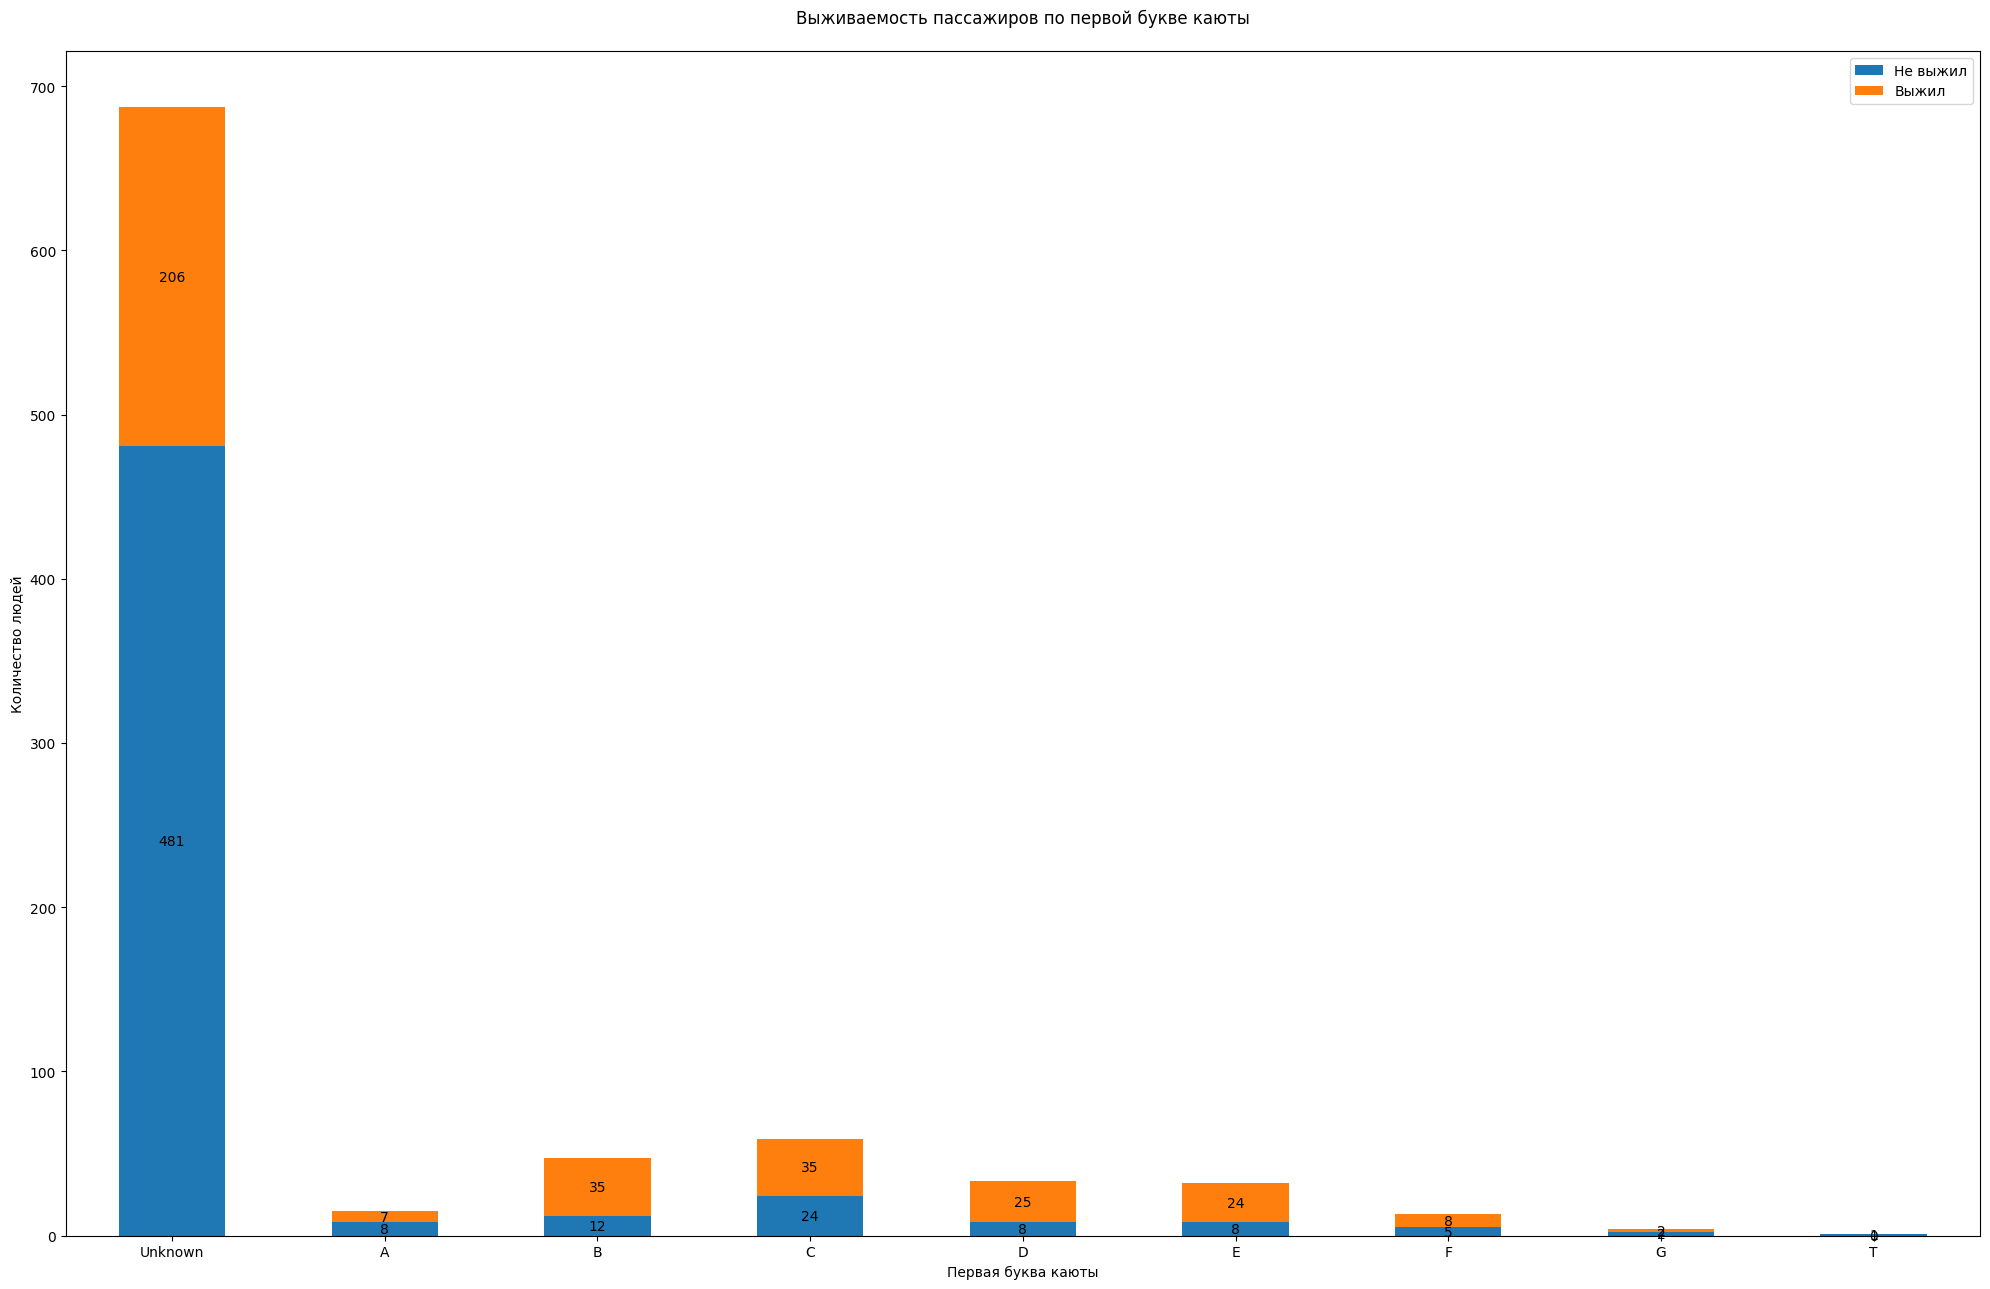

In [19]:
# 1. Создание новой колонки 'Cabin_letter'
df['Cabin_letter'] = df['Cabin'].str[0]  # Берем первую букву
df['Cabin_letter'] = df['Cabin_letter'].fillna('Unknown')  # Заменяем NaN на 'Unknown'

# 2. Подготовка данных
# Группируем по первой букве каюты и выжившим/невыжившим
survival_stats = df.groupby(['Cabin_letter', 'Survived']).size().unstack(fill_value=0)

# Создаем DataFrame с нужной структурой
stats = pd.DataFrame({
    'Unknown': {
        'Не выжил': survival_stats.loc['Unknown', 0],
        'Выжил': survival_stats.loc['Unknown', 1]
    },
    'A': {
        'Не выжил': survival_stats.loc['A', 0],
        'Выжил': survival_stats.loc['A', 1]
    },
    'B': {
        'Не выжил': survival_stats.loc['B', 0],
        'Выжил': survival_stats.loc['B', 1]
    },
    'C': {
        'Не выжил': survival_stats.loc['C', 0],
        'Выжил': survival_stats.loc['C', 1]
    },
    'D': {
        'Не выжил': survival_stats.loc['D', 0],
        'Выжил': survival_stats.loc['D', 1]
    },
    'E': {
        'Не выжил': survival_stats.loc['E', 0],
        'Выжил': survival_stats.loc['E', 1]
    },
    'F': {
        'Не выжил': survival_stats.loc['F', 0],
        'Выжил': survival_stats.loc['F', 1]
    },
    'G': {
        'Не выжил': survival_stats.loc['G', 0],
        'Выжил': survival_stats.loc['G', 1]
    },
    'T': {
        'Не выжил': survival_stats.loc['T', 0],
        'Выжил': survival_stats.loc['T', 1]
    }
})

# 3. Вывод статистики
print("\nПроцент выживших по первой букве каюты:")
for group in stats.columns:
    total = stats[group].sum()
    survived = stats[group]['Выжил']
    print(f"{group}: {round(survived/total*100, 1)}% выживших")

# 4. Построение графика
ax = stats.T.plot(kind='bar', stacked=True, figsize=(20, 13))
plt.title('Выживаемость пассажиров по первой букве каюты', pad=20)
plt.ylabel('Количество людей')
plt.xlabel('Первая буква каюты')

# 5. Добавление подписей значений
for container in ax.containers:
    ax.bar_label(container, label_type='center')

# 6. Настройка отображения
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()


Хоть графики получились и не совсем хорошими, зато в процентных соотношениях мы можем наблюдать, что лидер по выживаемости - D: 75.8% выживших

# 3. Выводы

1. Чаще выживали женщины
2. Чаще выживали дети
3. Пожилые люди выжывали реже
4. Чем выше класс, тем выше шанс выжить
5. Наличие родственников повышает шанс на выживание
6. Если пассажир из порта S, то у него выше шанс выжить
7. В кабинах, которые начинаются на D люди выживали чаще всего


## 4.Создание и изменение признаков #TODO Сергей


Приступаем к feature engeneering

Объединяем колонки SibSp и Parch

In [20]:
from copy import copy

new_df = copy(df)
new_df['Family'] = df['SibSp'] + df['Parch']
new_df

,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked,Pclass_category,Cabin_letter,Family
0,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S,3 класс,Unknown,1
1,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C,1 класс,C,1
2,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S,3 класс,Unknown,0
3,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S,1 класс,C,1
4,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S,3 класс,Unknown,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
886,0,2,"Montvila, Rev. Juozas",male,27.0,0,0,211536,13.0000,NaN,S,2 класс,Unknown,0
887,1,1,"Graham, Miss. Margaret Edith",female,19.0,0,0,112053,30.0000,B42,S,1 класс,B,0
888,0,3,"Johnston, Miss. Catherine Helen ""Carrie""",female,NaN,1,2,W./C. 6607,23.4500,NaN,S,3 класс,Unknown,3
889,1,1,"Behr, Mr. Karl Howell",male,26.0,0,0,111369,30.0000,C148,C,1 класс,C,0


Делим пассажиров на группы по возрасту: Child (0-18), Adult (18-60) и Elderly (60+).


In [21]:
new_df['AgeGroup'] = pd.cut(new_df['Age'], bins=[0,18,60,100], labels=[1, 2, 3])
new_df['AgeGroup'].value_counts()

,count
AgeGroup,
2,553
1,139
3,22


 Также выделим в отдельный признак первую букву номера каюты

In [22]:
new_df['CabinDeck'] = df['Cabin'].str[0]
new_df

,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked,Pclass_category,Cabin_letter,Family,AgeGroup,CabinDeck
0,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S,3 класс,Unknown,1,2,NaN
1,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C,1 класс,C,1,2,C
2,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S,3 класс,Unknown,0,2,NaN
3,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S,1 класс,C,1,2,C
4,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S,3 класс,Unknown,0,2,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
886,0,2,"Montvila, Rev. Juozas",male,27.0,0,0,211536,13.0000,NaN,S,2 класс,Unknown,0,2,NaN
887,1,1,"Graham, Miss. Margaret Edith",female,19.0,0,0,112053,30.0000,B42,S,1 класс,B,0,2,B
888,0,3,"Johnston, Miss. Catherine Helen ""Carrie""",female,NaN,1,2,W./C. 6607,23.4500,NaN,S,3 класс,Unknown,3,NaN,NaN
889,1,1,"Behr, Mr. Karl Howell",male,26.0,0,0,111369,30.0000,C148,C,1 класс,C,0,2,C


Займемся норматизацией

In [23]:
new_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 16 columns):
 #   Column           Non-Null Count  Dtype   
---  ------           --------------  -----   
 0   Survived         891 non-null    int64   
 1   Pclass           891 non-null    int64   
 2   Name             891 non-null    object  
 3   Sex              891 non-null    object  
 4   Age              714 non-null    float64 
 5   SibSp            891 non-null    int64   
 6   Parch            891 non-null    int64   
 7   Ticket           891 non-null    object  
 8   Fare             891 non-null    float64 
 9   Cabin            204 non-null    object  
 10  Embarked         889 non-null    object  
 11  Pclass_category  891 non-null    object  
 12  Cabin_letter     891 non-null    object  
 13  Family           891 non-null    int64   
 14  AgeGroup         714 non-null    category
 15  CabinDeck        204 non-null    object  
dtypes: category(1), float64(2), int64(5), object

Избавимся от category. Для этого сменим Nan на 1, после чего поменяем тип на int64.

In [24]:
new_df['AgeGroup'].fillna(1, inplace=True)
categorical_cols = new_df.select_dtypes(include=['category']).columns
for col in categorical_cols:
    new_df[col] = new_df[col].astype(np.int64)
new_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 16 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   Survived         891 non-null    int64  
 1   Pclass           891 non-null    int64  
 2   Name             891 non-null    object 
 3   Sex              891 non-null    object 
 4   Age              714 non-null    float64
 5   SibSp            891 non-null    int64  
 6   Parch            891 non-null    int64  
 7   Ticket           891 non-null    object 
 8   Fare             891 non-null    float64
 9   Cabin            204 non-null    object 
 10  Embarked         889 non-null    object 
 11  Pclass_category  891 non-null    object 
 12  Cabin_letter     891 non-null    object 
 13  Family           891 non-null    int64  
 14  AgeGroup         891 non-null    int64  
 15  CabinDeck        204 non-null    object 
dtypes: float64(2), int64(6), object(8)
memory usage: 111.5+ KB


<ipython-input-24-7e7d32b3d451>:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  new_df['AgeGroup'].fillna(1, inplace=True)


уберем тип object

In [25]:
categorical_cols = df.select_dtypes(include=['object']).columns
label_encoders = {}
for col in categorical_cols:
    le = LabelEncoder()
    new_df[col] = le.fit_transform(new_df[col])
    label_encoders[col] = le
new_df

,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked,Pclass_category,Cabin_letter,Family,AgeGroup,CabinDeck
0,0,3,108,1,22.0,1,0,523,7.2500,147,2,2,8,1,2,NaN
1,1,1,190,0,38.0,1,0,596,71.2833,81,0,0,2,1,2,C
2,1,3,353,0,26.0,0,0,669,7.9250,147,2,2,8,0,2,NaN
3,1,1,272,0,35.0,1,0,49,53.1000,55,2,0,2,1,2,C
4,0,3,15,1,35.0,0,0,472,8.0500,147,2,2,8,0,2,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
886,0,2,548,1,27.0,0,0,101,13.0000,147,2,1,8,0,2,NaN
887,1,1,303,0,19.0,0,0,14,30.0000,30,2,0,1,0,2,B
888,0,3,413,0,NaN,1,2,675,23.4500,147,2,2,8,3,1,NaN
889,1,1,81,1,26.0,0,0,8,30.0000,60,0,0,2,0,2,C


In [26]:
new_df['CabinDeck'].value_counts()

,count
CabinDeck,
C,59
B,47
D,33
E,32
A,15
F,13
G,4
T,1


в связи с отсутствием большого колличества данных о первых буквах в номерах кают принимаю решение убрать эту колонку из коррреляции

In [27]:
new_df = new_df.drop(['CabinDeck'], axis=1)
new_df

,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked,Pclass_category,Cabin_letter,Family,AgeGroup
0,0,3,108,1,22.0,1,0,523,7.2500,147,2,2,8,1,2
1,1,1,190,0,38.0,1,0,596,71.2833,81,0,0,2,1,2
2,1,3,353,0,26.0,0,0,669,7.9250,147,2,2,8,0,2
3,1,1,272,0,35.0,1,0,49,53.1000,55,2,0,2,1,2
4,0,3,15,1,35.0,0,0,472,8.0500,147,2,2,8,0,2
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
886,0,2,548,1,27.0,0,0,101,13.0000,147,2,1,8,0,2
887,1,1,303,0,19.0,0,0,14,30.0000,30,2,0,1,0,2
888,0,3,413,0,NaN,1,2,675,23.4500,147,2,2,8,3,1
889,1,1,81,1,26.0,0,0,8,30.0000,60,0,0,2,0,2


Теперь пришло время избавиться от нулей

In [28]:
new_df.isnull().sum()

,0
Survived,0
Pclass,0
Name,0
Sex,0
Age,177
SibSp,0
Parch,0
Ticket,0
Fare,0
Cabin,0


заменим нули в Age медианным значением

In [29]:
new_df['Age'].fillna(new_df['Age'].median(), inplace=True)
new_df.isnull().sum()
new_df

<ipython-input-29-e3e21f52bab4>:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  new_df['Age'].fillna(new_df['Age'].median(), inplace=True)


,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked,Pclass_category,Cabin_letter,Family,AgeGroup
0,0,3,108,1,22.0,1,0,523,7.2500,147,2,2,8,1,2
1,1,1,190,0,38.0,1,0,596,71.2833,81,0,0,2,1,2
2,1,3,353,0,26.0,0,0,669,7.9250,147,2,2,8,0,2
3,1,1,272,0,35.0,1,0,49,53.1000,55,2,0,2,1,2
4,0,3,15,1,35.0,0,0,472,8.0500,147,2,2,8,0,2
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
886,0,2,548,1,27.0,0,0,101,13.0000,147,2,1,8,0,2
887,1,1,303,0,19.0,0,0,14,30.0000,30,2,0,1,0,2
888,0,3,413,0,28.0,1,2,675,23.4500,147,2,2,8,3,1
889,1,1,81,1,26.0,0,0,8,30.0000,60,0,0,2,0,2


Теперь, когда данные без пробелов можно приступать к обучению модели.

# 5. Обучение

In [30]:
new_df.corr()

,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked,Pclass_category,Cabin_letter,Family,AgeGroup
Survived,1.000000,-0.338481,-0.057343,-0.543351,-0.064910,-0.035322,0.081629,-0.164549,0.257307,-0.254888,-0.163517,-0.338481,-0.301116,0.016639,-0.018422
Pclass,-0.338481,1.000000,0.052831,0.131900,-0.339898,0.083081,0.018443,0.319869,-0.549500,0.684121,0.157112,1.000000,0.746616,0.065997,-0.264098
Name,-0.057343,0.052831,1.000000,0.020314,0.048252,-0.017230,-0.049105,0.047348,-0.049173,0.061959,-0.004557,0.052831,0.051093,-0.036309,-0.084280
Sex,-0.543351,0.131900,0.020314,1.000000,0.081163,-0.114631,-0.245489,0.059372,-0.182333,0.096681,0.104057,0.131900,0.123076,-0.200988,0.065008
Age,-0.064910,-0.339898,0.048252,0.081163,1.000000,-0.233296,-0.172482,-0.070382,0.096688,-0.240839,-0.014205,-0.339898,-0.255783,-0.245619,0.603536
SibSp,-0.035322,0.083081,-0.017230,-0.114631,-0.233296,1.000000,0.414838,0.079461,0.159651,0.043593,0.066654,0.083081,0.041540,0.890712,-0.231515
Parch,0.081629,0.018443,-0.049105,-0.245489,-0.172482,0.414838,1.000000,0.020003,0.216225,-0.028324,0.038322,0.018443,-0.032548,0.783111,-0.117362
Ticket,-0.164549,0.319869,0.047348,0.059372,-0.070382,0.079461,0.020003,1.000000,-0.013885,0.243696,-0.006041,0.319869,0.256307,0.064302,-0.026679
Fare,0.257307,-0.549500,-0.049173,-0.182333,0.096688,0.159651,0.216225,-0.013885,1.000000,-0.503355,-0.221226,-0.549500,-0.523013,0.217138,0.084233
Cabin,-0.254888,0.684121,0.061959,0.096681,-0.240839,0.043593,-0.028324,0.243696,-0.503355,1.000000,0.193205,0.684121,0.947729,0.015644,-0.170241


Видим сильную корреляцию некоторых значений

удаляем коррелирующие значения(Name, Age, SibSp, Parch, Ticket, Fare, Cabin)

In [31]:
new_df = new_df.drop(['Name', 'Age', 'SibSp', 'Parch', 'Ticket', 'Fare', 'Cabin'], axis=1)

(На самом деле удалять их было рано, но я случайно уже удалил эти значения и не смог их восстановить, поэтому попробую продолжить так)

In [32]:
new_df

,Survived,Pclass,Sex,Embarked,Pclass_category,Cabin_letter,Family,AgeGroup
0,0,3,1,2,2,8,1,2
1,1,1,0,0,0,2,1,2
2,1,3,0,2,2,8,0,2
3,1,1,0,2,0,2,1,2
4,0,3,1,2,2,8,0,2
...,...,...,...,...,...,...,...,...
886,0,2,1,2,1,8,0,2
887,1,1,0,2,0,1,0,2
888,0,3,0,2,2,8,3,1
889,1,1,1,0,0,2,0,2


создаем КАК ЭТО **НАЗВАТЬ** **Текст, выделенный полужирным шрифтом**

In [33]:
x = new_df.drop(columns=['Survived'])
y = new_df['Survived']

In [34]:
x

,Pclass,Sex,Embarked,Pclass_category,Cabin_letter,Family,AgeGroup
0,3,1,2,2,8,1,2
1,1,0,0,0,2,1,2
2,3,0,2,2,8,0,2
3,1,0,2,0,2,1,2
4,3,1,2,2,8,0,2
...,...,...,...,...,...,...,...
886,2,1,2,1,8,0,2
887,1,0,2,0,1,0,2
888,3,0,2,2,8,3,1
889,1,1,0,0,2,0,2


x - то, что мы будем кормить нейросети

In [35]:
y.value_counts()

,count
Survived,
0,549
1,342


смотрим что примерно должно получиться

# Первая модель(максимально простая)

In [36]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from keras.models import Sequential
from keras.layers import Dense

x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=42)

scaler = StandardScaler()
x_train = scaler.fit_transform(x_train)
x_test = scaler.transform(x_test)

model = Sequential()
model.add(Dense(32, activation='relu', input_shape=(x_train.shape[1],)))
model.add(Dense(16, activation='relu', input_shape=(x_train.shape[1],)))
model.add(Dense(1, activation='sigmoid'))

model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])

history = model.fit(x_train, y_train, epochs=30, batch_size=10, validation_split=0.2)

loss, accuracy = model.evaluate(x_test, y_test)
print(f'Test Accuracy: {accuracy:.2f}')

Epoch 1/30


/usr/local/lib/python3.11/dist-packages/keras/src/layers/core/dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


57/57 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step - accuracy: 0.5397 - loss: 0.7054 - val_accuracy: 0.8182 - val_loss: 0.5522
Epoch 2/30
57/57 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.7840 - loss: 0.5554 - val_accuracy: 0.8252 - val_loss: 0.4547
Epoch 3/30
57/57 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.7982 - loss: 0.4919 - val_accuracy: 0.8462 - val_loss: 0.4174
Epoch 4/30
57/57 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.8122 - loss: 0.4525 - val_accuracy: 0.8322 - val_loss: 0.3956
Epoch 5/30
57/57 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.7868 - loss: 0.4984 - val_accuracy: 0.8462 - val_loss: 0.3827
Epoch 6/30
57/57 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.8419 - loss: 0.3861 - val_accuracy: 0.8531 - val_loss: 0.3787
Epoch 7/30
57/57 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.7642 - loss: 0.4635 - val_accuracy: 0.8462 - val_loss: 0.3795
Epoch 8/30
57/57 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.8299 - loss: 0.4063 - val_accuracy: 0.8462 - val_loss: 0.3787
Epo

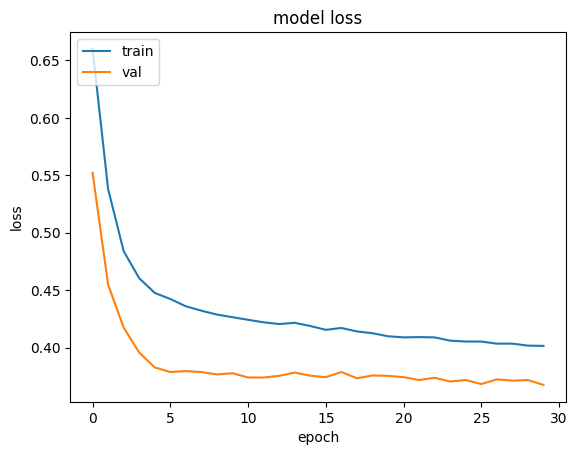

In [37]:
plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])
plt.title('model loss')
plt.ylabel('loss')
plt.xlabel('epoch')
plt.legend(['train', 'val'], loc='upper left')
plt.show()

In [38]:
new_df.corr()

,Survived,Pclass,Sex,Embarked,Pclass_category,Cabin_letter,Family,AgeGroup
Survived,1.000000,-0.338481,-0.543351,-0.163517,-0.338481,-0.301116,0.016639,-0.018422
Pclass,-0.338481,1.000000,0.131900,0.157112,1.000000,0.746616,0.065997,-0.264098
Sex,-0.543351,0.131900,1.000000,0.104057,0.131900,0.123076,-0.200988,0.065008
Embarked,-0.163517,0.157112,0.104057,1.000000,0.157112,0.187015,0.064701,0.126103
Pclass_category,-0.338481,1.000000,0.131900,0.157112,1.000000,0.746616,0.065997,-0.264098
Cabin_letter,-0.301116,0.746616,0.123076,0.187015,0.746616,1.000000,0.012131,-0.189082
Family,0.016639,0.065997,-0.200988,0.064701,0.065997,0.012131,1.000000,-0.216865
AgeGroup,-0.018422,-0.264098,0.065008,0.126103,-0.264098,-0.189082,-0.216865,1.000000


In [39]:
import shap

def model_predict(features):
    return model.predict(features).flatten()


shap.initjs()

explainer = shap.KernelExplainer(model_predict, x_train)
shap_values = explainer.shap_values(x_test)

shap.summary_plot(shap_values, x_test, plot_type="bar")

23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step


  0%|          | 0/179 [00:00<?, ?it/s]

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 62ms/step
2804/2804 ━━━━━━━━━━━━━━━━━━━━ 4s 1ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 44ms/step
2804/2804 ━━━━━━━━━━━━━━━━━━━━ 5s 2ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 46ms/step
2804/2804 ━━━━━━━━━━━━━━━━━━━━ 4s 1ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 69ms/step
2804/2804 ━━━━━━━━━━━━━━━━━━━━ 4s 1ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 41ms/step
2804/2804 ━━━━━━━━━━━━━━━━━━━━ 4s 1ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 45ms/step
2804/2804 ━━━━━━━━━━━━━━━━━━━━ 4s 1ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 42ms/step
2804/2804 ━━━━━━━━━━━━━━━━━━━━ 5s 2ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 41ms/step
2804/2804 ━━━━━━━━━━━━━━━━━━━━ 4s 1ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 45ms/step
2804/2804 ━━━━━━━━━━━━━━━━━━━━ 4s 1ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 62ms/step
2804/2804 ━━━━━━━━━━━━━━━━━━━━ 4s 1ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 42ms/step
2804/2804 ━━━━━━━━━━━━━━━━━━━━ 4s 1ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 41ms/step
2804/2804 ━━━━━━━━━━━━━━━━━━━━ 5s 2ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 

KeyboardInterrupt: 

In [40]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from keras.models import Sequential
from keras.layers import Dense

x_train, x_test, y_train, y_test = train_test_split(x_1, y, test_size=0.2, random_state=42)

scaler = StandardScaler()
x_train = scaler.fit_transform(x_train)
x_test = scaler.transform(x_test)

model = Sequential()
model.add(Dense(128, activation='relu', input_shape=(x_train.shape[1],)))
model.add(Dense(64, activation='relu', input_shape=(x_train.shape[1],)))
model.add(Dense(32, activation='relu', input_shape=(x_train.shape[1],)))
model.add(Dense(1, activation='sigmoid'))

model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])

history = model.fit(x_train, y_train, epochs=30, batch_size=10, validation_split=0.2)

loss, accuracy = model.evaluate(x_test, y_test)
print(f'Test Accuracy: {accuracy:.2f}')

NameError: name 'x_1' is not defined